In [29]:
#import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [30]:
#load all datasets

train = pd.read_csv("../data/train.csv")
stores = pd.read_csv("../data/stores.csv")
features = pd.read_csv("../data/features.csv")

In [31]:
print("Train shape:", train.shape)
print("Stores shape:", stores.shape)
print("Features shape:", features.shape)

Train shape: (421570, 5)
Stores shape: (45, 3)
Features shape: (8190, 12)


In [32]:
print("Train columns:")
print(train.columns.tolist())

print("\nStores columns:")
print(stores.columns.tolist())

print("\nFeatures columns:")
print(features.columns.tolist())

Train columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Stores columns:
['Store', 'Type', 'Size']

Features columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']


In [33]:
print(train["Date"].head(10).tolist())
print(features["Date"].head(10).tolist())

['2010-02-05', '2010-02-12', '2010-02-19', '2010-02-26', '2010-03-05', '2010-03-12', '2010-03-19', '2010-03-26', '2010-04-02', '2010-04-09']
['2010-02-05', '2010-02-12', '2010-02-19', '2010-02-26', '2010-03-05', '2010-03-12', '2010-03-19', '2010-03-26', '2010-04-02', '2010-04-09']


In [34]:
#convert dates

train["Date"] = pd.to_datetime(
    train["Date"],
    format="%Y-%m-%d",
    errors="raise"
)

features["Date"] = pd.to_datetime(
    features["Date"],
    format="%Y-%m-%d",
    errors="raise"
)

In [35]:
print(train["Date"].head())
print(features["Date"].head())

print(train["Date"].isna().sum())
print(features["Date"].isna().sum())

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[us]
0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[us]
0
0


In [36]:
print(train["Date"].dtype)
print(features["Date"].dtype)

print("Train date range:", train["Date"].min(), "to", train["Date"].max())
print("Invalid train dates:", train["Date"].isna().sum())
print("Invalid feature dates:", features["Date"].isna().sum())

datetime64[us]
datetime64[us]
Train date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Invalid train dates: 0
Invalid feature dates: 0


In [37]:
#merger datasets

df = pd.merge(
    train,
    stores,
    on="Store",
    how="left",
    validate="many_to_one"
)

df = pd.merge(
    df,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left",
    validate="many_to_one"
)

print("Train rows:", len(train))
print("Merged rows:", len(df))
print("Merged shape:", df.shape)

df.head()

Train rows: 421570
Merged rows: 421570
Merged shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [38]:
#checked merged datasets

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421570 non-nul

In [39]:
#missing values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_values = missing_values[
    missing_values["Missing Values"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_values

,Missing Values,Missing Percentage
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08


In [40]:
#check duplicates

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [41]:
duplicate_keys = df.duplicated(
    subset=["Store", "Dept", "Date"],
    keep=False
)

print("Duplicate Store-Dept-Date records:", duplicate_keys.sum())

Duplicate Store-Dept-Date records: 0


In [42]:
#duplicated holiday columns

[col for col in df.columns if "Holiday" in col]

['IsHoliday']

In [43]:
df["IsHoliday"] = df["IsHoliday"].astype(int)

In [44]:
#remove exact duplicate rows

df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (421570, 16)


In [45]:
#understand missing values

markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_columns].isnull().sum()

MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64

In [46]:
df[markdown_columns] = df[markdown_columns].fillna(0)

In [47]:
#handle other numerical missing values

numerical_columns = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

df[numerical_columns].isnull().sum()

Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [51]:
# the data is time-based and store-specific, fill missing values using forward and backward filling within each store

df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

for column in numerical_columns:
    df[column] = (
        df.groupby("Store")[column]
        .transform(lambda series: series.ffill().bfill())
    )

In [52]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [53]:
df[numerical_columns].isnull().sum()

Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [54]:
#handle missing categorical values

df[["Type", "Size"]].isnull().sum()

Type    0
Size    0
dtype: int64

In [55]:
#checked unmatched stores 
df[df["Type"].isnull()][["Store"]].drop_duplicates()

,Store


In [56]:
#create date based features

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["DayOfMonth"] = df["Date"].dt.day

In [57]:
df[
    [
        "Date",
        "Year",
        "Month",
        "Quarter",
        "WeekOfYear",
        "DayOfWeek"
    ]
].head()

,Date,Year,Month,Quarter,WeekOfYear,DayOfWeek
0,2010-02-05,2010,2,1,5,4
1,2010-02-05,2010,2,1,5,4
2,2010-02-05,2010,2,1,5,4
3,2010-02-05,2010,2,1,5,4
4,2010-02-05,2010,2,1,5,4


In [58]:
#create seasonal features

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

In [59]:
df[["Month", "Season"]].drop_duplicates().sort_values("Month")

,Month,Season
3443,1,Winter
0,2,Winter
290,3,Spring
580,4,Spring
941,5,Spring
1225,6,Summer
1505,7,Summer
1863,8,Summer
2146,9,Autumn
2433,10,Autumn


In [60]:
#create cyclical time features 

df["Month_Sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_Cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df["Week_Sin"] = np.sin(2 * np.pi * df["WeekOfYear"] / 52)
df["Week_Cos"] = np.cos(2 * np.pi * df["WeekOfYear"] / 52)

In [61]:
#sort data before creating lag features

df = df.sort_values(
    by=["Store", "Dept", "Date"]
).reset_index(drop=True)

In [62]:
#create lag features

grouped_sales = df.groupby(["Store", "Dept"])["Weekly_Sales"]

df["Sales_Lag_1"] = grouped_sales.shift(1)
df["Sales_Lag_2"] = grouped_sales.shift(2)
df["Sales_Lag_4"] = grouped_sales.shift(4)
df["Sales_Lag_8"] = grouped_sales.shift(8)
df["Sales_Lag_12"] = grouped_sales.shift(12)

In [63]:
#check one store and one department 

df.loc[
    (df["Store"] == 1) & (df["Dept"] == 1),
    [
        "Date",
        "Weekly_Sales",
        "Sales_Lag_1",
        "Sales_Lag_4",
        "Sales_Lag_12"
    ]
].head(15)

,Date,Weekly_Sales,Sales_Lag_1,Sales_Lag_4,Sales_Lag_12
0,2010-02-05,24924.50,NaN,NaN,NaN
1,2010-02-12,46039.49,24924.50,NaN,NaN
2,2010-02-19,41595.55,46039.49,NaN,NaN
3,2010-02-26,19403.54,41595.55,NaN,NaN
4,2010-03-05,21827.90,19403.54,24924.50,NaN
5,2010-03-12,21043.39,21827.90,46039.49,NaN
6,2010-03-19,22136.64,21043.39,41595.55,NaN
7,2010-03-26,26229.21,22136.64,19403.54,NaN
8,2010-04-02,57258.43,26229.21,21827.90,NaN
9,2010-04-09,42960.91,57258.43,21043.39,NaN


In [65]:
#create rolling features without data leakage

df = df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

df["Rolling_Mean"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.rolling(window=4, min_periods=1).mean())
)

In [66]:
df["Rolling_Mean_4"] = (
    grouped_sales
    .transform(lambda series: series.shift(1).rolling(4).mean())
)

df["Rolling_Mean_8"] = (
    grouped_sales
    .transform(lambda series: series.shift(1).rolling(8).mean())
)

df["Rolling_Std_4"] = (
    grouped_sales
    .transform(lambda series: series.shift(1).rolling(4).std())
)

In [67]:
#create expanding historical average 

df["Historical_Avg_Sales"] = (
    grouped_sales
    .transform(lambda series: series.shift(1).expanding().mean())
)

In [68]:
#create promotion-related features
df["Has_Markdown"] = (
    df[markdown_columns].sum(axis=1) > 0
).astype(int)

In [69]:
#craete total markdowns 
df["Total_Markdown"] = df[markdown_columns].sum(axis=1)

In [70]:
df[
    markdown_columns + ["Has_Markdown", "Total_Markdown"]
].head()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Has_Markdown,Total_Markdown
0,0.0,0.0,0.0,0.0,0.0,0,0.0
1,0.0,0.0,0.0,0.0,0.0,0,0.0
2,0.0,0.0,0.0,0.0,0.0,0,0.0
3,0.0,0.0,0.0,0.0,0.0,0,0.0
4,0.0,0.0,0.0,0.0,0.0,0,0.0


In [71]:
#create store size category
df["Store_Size_Category"] = pd.qcut(
    df["Size"],
    q=3,
    labels=["Small", "Medium", "Large"],
    duplicates="drop"
)

In [72]:
df[
    ["Store", "Size", "Store_Size_Category"]
].drop_duplicates().head(20)

,Store,Size,Store_Size_Category
0,1,151315,Medium
10244,2,202307,Large
20482,3,37392,Small
29518,4,205863,Large
39790,5,34875,Small
48789,6,202505,Large
59000,7,70713,Small
68762,8,155078,Medium
78657,9,125833,Medium
87524,10,126512,Medium


In [73]:
#check negative sales
negative_sales = df[df["Weekly_Sales"] < 0]

print("Negative sales records:", len(negative_sales))

negative_sales[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].head()

Negative sales records: 1285


,Store,Dept,Date,Weekly_Sales
846,1,6,2012-08-10,-139.65
2384,1,18,2012-05-04,-1.27
6048,1,47,2010-02-19,-863.00
6049,1,47,2010-03-12,-698.00
6051,1,47,2010-10-08,-58.00


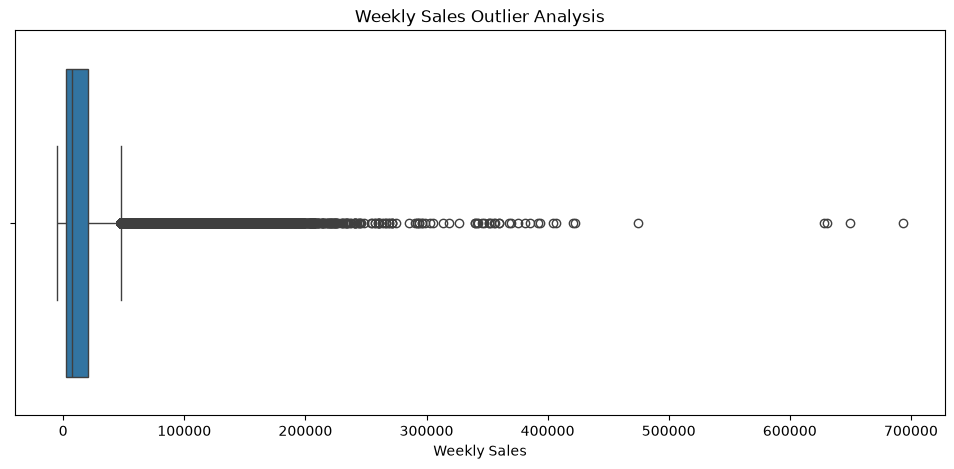

In [74]:
#check outliers
plt.figure(figsize=(12, 5))

sns.boxplot(x=df["Weekly_Sales"])

plt.title("Weekly Sales Outlier Analysis")
plt.xlabel("Weekly Sales")
plt.show()

In [75]:
#calculate IQR

q1 = df["Weekly_Sales"].quantile(0.25)
q3 = df["Weekly_Sales"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

print(
    "Number of potential outliers:",
    ((df["Weekly_Sales"] < lower_limit) |
     (df["Weekly_Sales"] > upper_limit)).sum()
)

Lower limit: -25109.653749999998
Upper limit: 47395.15625
Number of potential outliers: 35521


In [76]:
#encode categorical features

df.select_dtypes(include="object").columns.tolist()

C:\Users\sanik\AppData\Local\Temp\ipykernel_26196\439847478.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns.tolist()


['Type', 'Season']

In [77]:
df = pd.get_dummies(
    df,
    columns=["Type", "Season", "Store_Size_Category"],
    drop_first=False,
    dtype=int
)

In [78]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Quarter,WeekOfYear,DayOfWeek,DayOfMonth,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Sales_Lag_1,Sales_Lag_2,Sales_Lag_4,Sales_Lag_8,Sales_Lag_12,Rolling_Mean,Rolling_Mean_4,Rolling_Mean_8,Rolling_Std_4,Historical_Avg_Sales,Has_Markdown,Total_Markdown,Type_A,Type_B,Type_C,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Store_Size_Category_Small,Store_Size_Category_Medium,Store_Size_Category_Large
0,1,1,2010-02-05,24924.50,0,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2010,2,1,5,4,5,0.866025,5.000000e-01,0.568065,0.822984,NaN,NaN,NaN,NaN,NaN,24924.500000,NaN,NaN,NaN,NaN,0,0.0,1,0,0,0,0,0,1,0,1,0
1,1,1,2010-02-12,46039.49,1,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2010,2,1,6,4,12,0.866025,5.000000e-01,0.663123,0.748511,24924.50,NaN,NaN,NaN,NaN,35481.995000,NaN,NaN,NaN,24924.500000,0,0.0,1,0,0,0,0,0,1,0,1,0
2,1,1,2010-02-19,41595.55,0,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2010,2,1,7,4,19,0.866025,5.000000e-01,0.748511,0.663123,46039.49,24924.50,NaN,NaN,NaN,37519.846667,NaN,NaN,NaN,35481.995000,0,0.0,1,0,0,0,0,0,1,0,1,0
3,1,1,2010-02-26,19403.54,0,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,2010,2,1,8,4,26,0.866025,5.000000e-01,0.822984,0.568065,41595.55,46039.49,NaN,NaN,NaN,32990.770000,NaN,NaN,NaN,37519.846667,0,0.0,1,0,0,0,0,0,1,0,1,0
4,1,1,2010-03-05,21827.90,0,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,2010,3,1,9,4,5,1.000000,6.123234e-17,0.885456,0.464723,19403.54,41595.55,24924.5,NaN,NaN,32216.620000,32990.77,NaN,12832.106391,32990.770000,0,0.0,1,0,0,0,1,0,0,0,1,0


In [79]:
#Check missing values created by lag features

lag_columns = [
    "Sales_Lag_1",
    "Sales_Lag_2",
    "Sales_Lag_4",
    "Sales_Lag_8",
    "Sales_Lag_12",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Std_4",
    "Historical_Avg_Sales"
]

df[lag_columns].isnull().sum()

Sales_Lag_1              3331
Sales_Lag_2              6625
Sales_Lag_4             13134
Sales_Lag_8             25966
Sales_Lag_12            38615
Rolling_Mean_4          13134
Rolling_Mean_8          25966
Rolling_Std_4           13134
Historical_Avg_Sales     3331
dtype: int64

In [80]:
processed_df = df.dropna(subset=lag_columns).copy()

In [81]:
print("Original rows:", len(df))
print("Processed rows:", len(processed_df))
print("Rows removed:", len(df) - len(processed_df))

Original rows: 421570
Processed rows: 382955
Rows removed: 38615


In [82]:
#verify the final dataset

print("Final shape:", processed_df.shape)
print("Total missing values:", processed_df.isnull().sum().sum())
print("Duplicate rows:", processed_df.duplicated().sum())

Final shape: (382955, 47)
Total missing values: 0
Duplicate rows: 0


In [83]:
processed_df.info()

<class 'pandas.DataFrame'>
Index: 382955 entries, 12 to 421569
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Store                       382955 non-null  int64         
 1   Dept                        382955 non-null  int64         
 2   Date                        382955 non-null  datetime64[us]
 3   Weekly_Sales                382955 non-null  float64       
 4   IsHoliday                   382955 non-null  int64         
 5   Size                        382955 non-null  int64         
 6   Temperature                 382955 non-null  float64       
 7   Fuel_Price                  382955 non-null  float64       
 8   MarkDown1                   382955 non-null  float64       
 9   MarkDown2                   382955 non-null  float64       
 10  MarkDown3                   382955 non-null  float64       
 11  MarkDown4                   382955 non-null  float64  

In [84]:
processed_df[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "Sales_Lag_1",
        "Sales_Lag_4",
        "Rolling_Mean_4",
        "Month",
        "WeekOfYear",
        "IsHoliday"
    ]
].head(10)

,Store,Dept,Date,Weekly_Sales,Sales_Lag_1,Sales_Lag_4,Rolling_Mean_4,Month,WeekOfYear,IsHoliday
12,1,1,2010-04-30,16555.11,16145.35,57258.43,33490.4125,4,17,0
13,1,1,2010-05-07,17413.94,16555.11,42960.91,23314.5825,5,18,0
14,1,1,2010-05-14,18926.74,17413.94,17596.96,16927.8400,5,19,0
15,1,1,2010-05-21,14773.04,18926.74,16145.35,17260.2850,5,20,0
16,1,1,2010-05-28,15580.43,14773.04,16555.11,16917.2075,5,21,0
17,1,1,2010-06-04,17558.09,15580.43,17413.94,16673.5375,6,22,0
18,1,1,2010-06-11,16637.62,17558.09,18926.74,16709.5750,6,23,0
19,1,1,2010-06-18,16216.27,16637.62,14773.04,16137.2950,6,24,0
20,1,1,2010-06-25,16328.72,16216.27,15580.43,16498.1025,6,25,0
21,1,1,2010-07-02,16333.14,16328.72,17558.09,16685.1750,7,26,0


In [85]:
#create feature summary

feature_summary = pd.DataFrame({
    "Feature": processed_df.columns,
    "Data Type": processed_df.dtypes.astype(str),
    "Missing Values": processed_df.isnull().sum().values,
    "Unique Values": processed_df.nunique().values
})

feature_summary

,Feature,Data Type,Missing Values,Unique Values
Store,Store,int64,0,45
Dept,Dept,int64,0,78
Date,Date,datetime64[us],0,131
Weekly_Sales,Weekly_Sales,float64,0,331983
IsHoliday,IsHoliday,int64,0,2
Size,Size,int64,0,40
Temperature,Temperature,float64,0,3292
Fuel_Price,Fuel_Price,float64,0,837
MarkDown1,MarkDown1,float64,0,2278
MarkDown2,MarkDown2,float64,0,1499


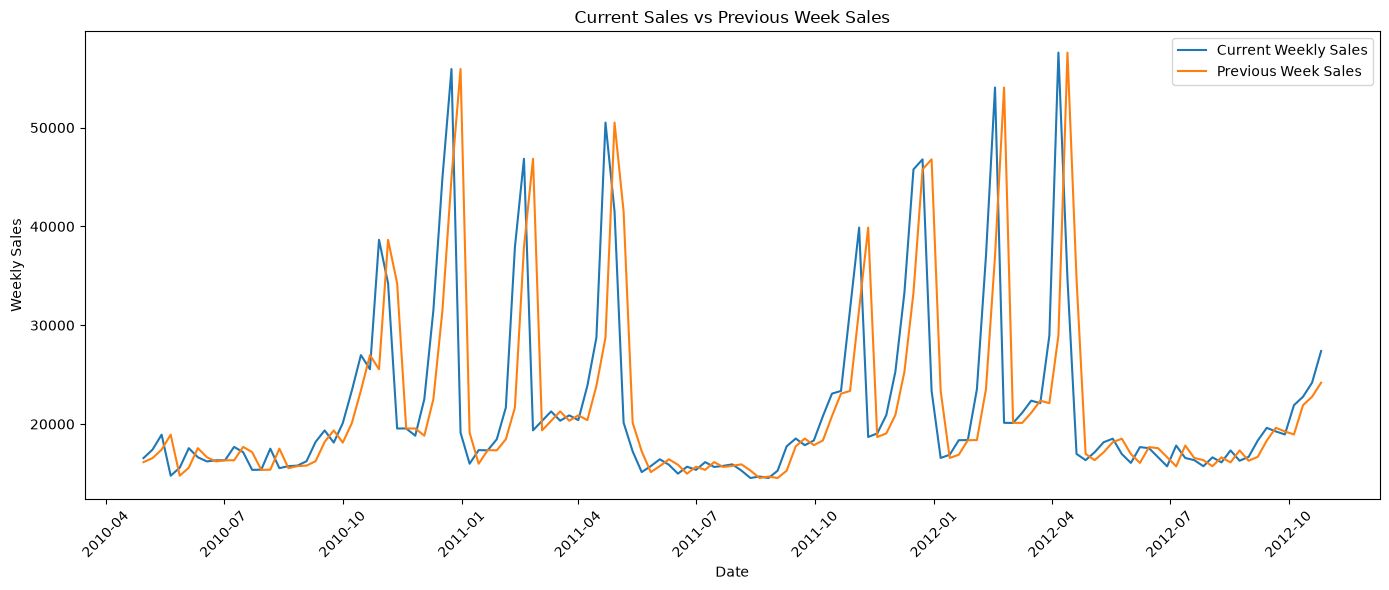

In [86]:
#plot lag relationship

sample = processed_df[
    (processed_df["Store"] == 1) &
    (processed_df["Dept"] == 1)
].copy()

plt.figure(figsize=(14, 6))

plt.plot(
    sample["Date"],
    sample["Weekly_Sales"],
    label="Current Weekly Sales"
)

plt.plot(
    sample["Date"],
    sample["Sales_Lag_1"],
    label="Previous Week Sales"
)

plt.title("Current Sales vs Previous Week Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

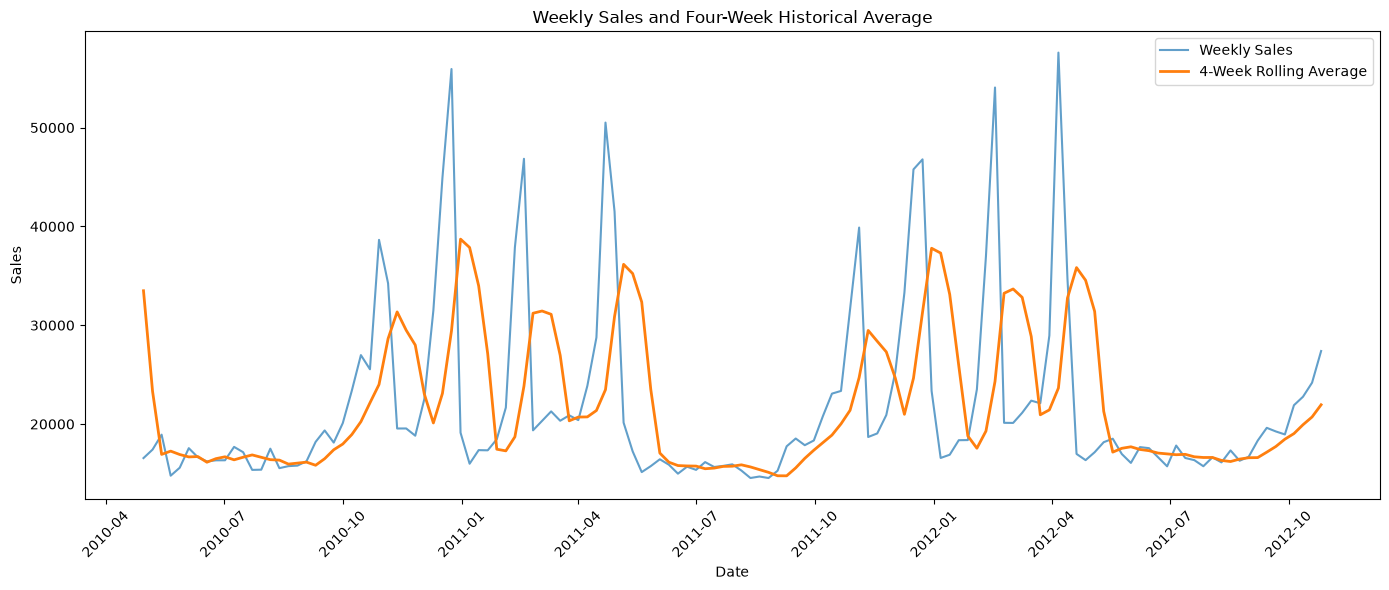

In [87]:
#plot rolling average

plt.figure(figsize=(14, 6))

plt.plot(
    sample["Date"],
    sample["Weekly_Sales"],
    label="Weekly Sales",
    alpha=0.7
)

plt.plot(
    sample["Date"],
    sample["Rolling_Mean_4"],
    label="4-Week Rolling Average",
    linewidth=2
)

plt.title("Weekly Sales and Four-Week Historical Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
processed_df.to_csv(
    "../data/processed/processed_walmart_sales.csv",
    index=False
)

In [90]:
saved_df = pd.read_csv(
    "../data/processed/processed_walmart_sales.csv"
)

print(saved_df.shape)
saved_df.head()

(382955, 47)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Quarter,WeekOfYear,DayOfWeek,DayOfMonth,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Sales_Lag_1,Sales_Lag_2,Sales_Lag_4,Sales_Lag_8,Sales_Lag_12,Rolling_Mean,Rolling_Mean_4,Rolling_Mean_8,Rolling_Std_4,Historical_Avg_Sales,Has_Markdown,Total_Markdown,Type_A,Type_B,Type_C,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Store_Size_Category_Small,Store_Size_Category_Medium,Store_Size_Category_Large
0,1,1,2010-04-30,16555.11,0,151315,67.41,2.780,0.0,0.0,0.0,0.0,0.0,210.389546,7.808,2010,4,2,17,4,30,0.866025,-0.500000,0.885456,-0.464723,16145.35,17596.96,57258.43,21827.90,24924.50,23314.5825,33490.4125,28149.84875,20067.070906,29763.489167,0,0.0,1,0,0,0,1,0,0,0,1,0
1,1,1,2010-05-07,17413.94,0,151315,72.55,2.835,0.0,0.0,0.0,0.0,0.0,210.339968,7.808,2010,5,2,18,4,7,0.500000,-0.866025,0.822984,-0.568065,16555.11,16145.35,42960.91,21043.39,46039.49,16927.8400,23314.5825,27490.75000,13111.798178,28747.460000,0,0.0,1,0,0,0,1,0,0,0,1,0
2,1,1,2010-05-14,18926.74,0,151315,74.78,2.854,0.0,0.0,0.0,0.0,0.0,210.337426,7.808,2010,5,2,19,4,14,0.500000,-0.866025,0.748511,-0.663123,17413.94,16555.11,17596.96,22136.64,41595.55,17260.2850,16927.8400,27037.06875,691.672619,27937.922857,0,0.0,1,0,0,0,1,0,0,0,1,0
3,1,1,2010-05-21,14773.04,0,151315,76.44,2.826,0.0,0.0,0.0,0.0,0.0,210.617093,7.808,2010,5,2,20,4,21,0.500000,-0.866025,0.663123,-0.748511,18926.74,17413.94,16145.35,26229.21,19403.54,16917.2075,17260.2850,26635.83125,1230.316214,27337.177333,0,0.0,1,0,0,0,1,0,0,0,1,0
4,1,1,2010-05-28,15580.43,0,151315,80.44,2.759,0.0,0.0,0.0,0.0,0.0,210.896761,7.808,2010,5,2,21,4,28,0.500000,-0.866025,0.568065,-0.822984,14773.04,18926.74,16555.11,57258.43,21827.90,16673.5375,16917.2075,25203.81000,1733.352524,26551.918750,0,0.0,1,0,0,0,1,0,0,0,1,0


In [91]:
## Day 2 Observations

# 1. Sales records were merged with store and external feature data using Store, Date and IsHoliday.
# 2. Missing markdown values were treated as zero because no markdown promotion was recorded for those weeks.
# 3. CPI, unemployment, temperature and fuel price were filled store-wise using historical values.
# 4. Calendar features such as month, week, quarter and year were created.
# 5. Lag features were calculated separately for every Store-Department combination.
# 6. Rolling features were shifted by one week to prevent target leakage.
# 7. Initial rows without sufficient sales history were removed from the processed dataset.
# 8. Extreme weekly sales were retained because they may represent genuine holiday demand.